In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
from dl import queryClient as qc
from dl import authClient as ac
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

# 登录Data Lab (匿名登录)
token = ac.login('anonymous')

## 查询DESI Legacy Surveys DR10 测光数据

从Data Lab查询恒星和QSO的grizW1W2测光数据。DR10数据表为 `ls_dr10.tractor`。

In [3]:
# 查看DR10 tractor表的列信息
schema_query = """
SELECT column_name, columns.datatype, description 
FROM tap_schema.columns 
WHERE table_name = 'ls_dr10.tractor'
AND (column_name LIKE '%flux%' OR column_name LIKE '%mag%' 
     OR column_name IN ('ra', 'dec', 'type', 'ls_id', 'ref_cat', 'ref_id'))
ORDER BY column_name
LIMIT 100
"""
schema_info = qc.query(sql=schema_query, fmt='pandas')
print("DR10 tractor表相关列:")
schema_info

DR10 tractor表相关列:


,column_name,datatype,description
0,dec,adql:DOUBLE,Declination at equinox J2000
1,dered_flux_g,adql:REAL,Dereddened g band flux
2,dered_flux_i,adql:REAL,Dereddened i band flux
3,dered_flux_r,adql:REAL,Dereddened r band flux
4,dered_flux_w1,adql:REAL,Dereddened w1 band flux
...,...,...,...
63,mag_z,adql:REAL,Converted g magnitude
64,ra,adql:DOUBLE,Right ascension at equinox J2000
65,ref_cat,adql:VARCHAR,Reference catalog source for this star: T2 for...
66,ref_id,adql:BIGINT,Reference catalog identifier for this star; Ty...


In [4]:
# 查看DESI DR1相关表
desi_tables_query = """
SELECT table_name, description
FROM tap_schema.tables
WHERE schema_name LIKE '%desi%'
ORDER BY table_name
"""
desi_tables = qc.query(sql=desi_tables_query, fmt='pandas')
print("DESI相关表:")
desi_tables

DESI相关表:


,table_name,description
0,desi_dr1.agnqso,Value-Added Catalog of DESI DR1 galaxies and q...
1,desi_dr1.emfit,Emission-Line flux and width measurements for ...
2,desi_dr1.exposure,"Summary quantities for every DESI exposure (9,..."
3,desi_dr1.fiberassign,Quantities obtained when a DESI target is assi...
4,desi_dr1.frame,Summary quantities for each petal of the DESI ...
5,desi_dr1.mws,"Milky Way Survey Value-Added Catalog (6,372,60..."
6,desi_dr1.photometry,Photometric quantities from LS DR9 for every T...
7,desi_dr1.potential,"For a given tile, this table lists all targets..."
8,desi_dr1.target,The quantities obtained when photometric objec...
9,desi_dr1.tile,Summary quantities for every DESI tile (pointi...


In [ ]:
# 查看DESI DR1主表的列信息（特别是分类和红移相关列）
desi_cols_query = """
SELECT column_name, data_type, description
FROM tap_schema.columns
WHERE table_name LIKE '%desi_dr1%'
AND (column_name LIKE '%spec%' OR column_name LIKE '%type%' 
     OR column_name LIKE '%class%' OR column_name LIKE '%target%'
     OR column_name IN ('ra', 'dec', 'z', 'zerr', 'zwarn', 'deltachi2', 
                        'targetid', 'survey', 'program'))
ORDER BY table_name, column_name
"""
desi_cols = qc.query(sql=desi_cols_query, fmt='pandas')
print("DESI DR1 分类相关列:")
desi_cols

In [5]:
def query_stars_qso_dr10_desi(ra_l, ra_u, dec_l, dec_u, obj_type='STAR'):
    """
    查询DR10测光数据并与DESI DR1交叉匹配获取恒星/QSO分类
    
    三表联合:
    - ls_dr10.tractor: DR10测光数据
    - desi_dr1.photometry: 有ra,dec坐标
    - desi_dr1.zpix: 光谱分类
    
    参数:
    ra_l, ra_u: RA范围
    dec_l, dec_u: Dec范围
    obj_type: 'STAR' 或 'QSO'
    
    返回: pandas DataFrame
    """
    
    query = f"""
        SELECT
            t.ls_id,
            t.ra, t.dec, 
            
            -- DESI DR1 光谱分类
            z.spectype,
            z.z AS z_spec,
            z.zerr,
            z.targetid,
            
            -- DR10 消光改正后的星等
            t.dered_mag_g, t.dered_mag_r, t.dered_mag_i, t.dered_mag_z,
            t.dered_mag_w1, t.dered_mag_w2,
            
            -- 颜色
            t.g_r, t.r_z, t.z_w1, t.w1_w2,
            
            -- 信噪比
            t.snr_g, t.snr_r, t.snr_i, t.snr_z, t.snr_w1, t.snr_w2,
            
            -- 质量标志
            t.fracflux_g, t.fracflux_r, t.fracflux_i, t.fracflux_z,
            t.fracmasked_g, t.fracmasked_r, t.fracmasked_i, t.fracmasked_z,
            t.fracin_g, t.fracin_r, t.fracin_i, t.fracin_z,
            t.allmask_g, t.allmask_r, t.allmask_i, t.allmask_z
            
        FROM
            ls_dr10.tractor AS t
        INNER JOIN
            desi_dr1.photometry AS p ON t.ls_id = p.ls_id
        INNER JOIN
            desi_dr1.zpix AS z ON p.targetid = z.targetid
        WHERE
            t.brick_primary = 1
            AND z.spectype = '{obj_type}'
            AND z.zwarn = 0
            AND t.ra >= {ra_l:.6f} AND t.ra < {ra_u:.6f}
            AND t.dec >= {dec_l:.6f} AND t.dec < {dec_u:.6f}

            AND t.dered_mag_g > 0 AND t.dered_mag_g < 30 AND t.snr_g > 0
            AND t.dered_mag_r > 0 AND t.dered_mag_r < 30 AND t.snr_r > 0
            AND t.dered_mag_z > 0 AND t.dered_mag_z < 30 AND t.snr_z > 0
            AND t.dered_mag_w1 > 0 AND t.dered_mag_w1 < 30 AND t.snr_w1 > 0
            AND t.dered_mag_w2 > 0 AND t.dered_mag_w2 < 30 AND t.snr_w2 > 0
    """
    
    print(f"查询 {obj_type} 数据...")
    result = qc.query(sql=query, fmt='pandas')
    print(f"返回 {len(result)} 条 {obj_type} 数据")
    
    return result

In [7]:
# 下载全天恒星数据
stars_df = query_stars_qso_dr10_desi(0, 360, -90, 90, obj_type='STAR')

# 转换为astropy Table并保存
stars_table = Table.from_pandas(stars_df)
path = './NonGal/LSDR10xDESIDR1_star.fits'
stars_table.write(path, format='fits', overwrite=True)
print(f"恒星数据已保存到 {path}，共 {len(stars_table)} 条")

查询 STAR 数据...
返回 1332548 条 STAR 数据
恒星数据已保存到 ./NonGal/LSDR10xDESIDR1_star.fits，共 1332548 条


In [8]:
# 下载全天QSO数据
qso_df = query_stars_qso_dr10_desi(0, 360, -90, 90, obj_type='QSO')

# 转换为astropy Table并保存
qso_table = Table.from_pandas(qso_df)
path = './NonGal/LSDR10xDESIDR1_qso.fits'
qso_table.write(path, format='fits', overwrite=True)
print(f"QSO数据已保存到 {path}，共 {len(qso_table)} 条")

查询 QSO 数据...
返回 353119 条 QSO 数据
QSO数据已保存到 ./NonGal/LSDR10xDESIDR1_qso.fits，共 353119 条


In [9]:
# 查看数据
print("=== 恒星数据 ===")
print(stars_df.info())
print(stars_df.head())

print("\n=== QSO数据 ===")
print(qso_df.info())
print(qso_df.head())

=== 恒星数据 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1332548 entries, 0 to 1332547
Data columns (total 39 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   ls_id         1332548 non-null  int64  
 1   ra            1332548 non-null  float64
 2   dec           1332548 non-null  float64
 3   spectype      1332548 non-null  object 
 4   z_spec        1332548 non-null  float64
 5   zerr          1332548 non-null  float64
 6   targetid      1332548 non-null  int64  
 7   dered_mag_g   1332548 non-null  float64
 8   dered_mag_r   1332548 non-null  float64
 9   dered_mag_i   1332548 non-null  int64  
 10  dered_mag_z   1332548 non-null  float64
 11  dered_mag_w1  1332548 non-null  float64
 12  dered_mag_w2  1332548 non-null  float64
 13  g_r           1332548 non-null  float64
 14  r_z           1332548 non-null  float64
 15  z_w1          1332548 non-null  float64
 16  w1_w2         1332548 non-null  float64
 17  snr_g         

## 查询 LS DR10 × SDSS DR17 恒星和QSO

In [13]:
# 查看SDSS DR17相关表
sdss_tables_query = """
SELECT table_name, description
FROM tap_schema.tables
WHERE schema_name LIKE '%sdss_dr17%'
ORDER BY table_name
"""
sdss_tables = qc.query(sql=sdss_tables_query, fmt='pandas')
print("SDSS DR17相关表:")
sdss_tables

SDSS DR17相关表:


,table_name,description
0,sdss_dr17.apogee2_allstar,APOGEE-2 DR17 final allStar catalog (Abdurro u...
1,sdss_dr17.eboss_dap_emlines,Value-added catalog of emission lines adapted ...
2,sdss_dr17.eboss_dap_emlines_high_ew,Value-added catalog of emission lines in high ...
3,sdss_dr17.eboss_dap_spind,"Value-added catalog of the spectral indices, a..."
4,sdss_dr17.eboss_dap_tplwgt,"Value-added catalog of the template weights, a..."
5,sdss_dr17.eboss_mcpm,The catalog containing matter density estimate...
6,sdss_dr17.photoplate,The full photometric catalog quantities for SD...
7,sdss_dr17.platex,Contains data from a given plate used for spec...
8,sdss_dr17.segue1specobjall,A view of specobjall that includes only SEGUE-...
9,sdss_dr17.segue2specobjall,A view of specobjall that includes only SEGUE-...


In [14]:
# 查看SDSS DR17 specobj表的列信息（分类相关）
sdss_cols_query = """
SELECT column_name, datatype, description
FROM tap_schema.columns
WHERE table_name = 'sdss_dr17.specobj'
AND (column_name LIKE '%class%' OR column_name LIKE '%type%' 
     OR column_name IN ('ra', 'dec', 'z', 'zerr', 'zwarning', 
                        'specobjid', 'bestobjid', 'fluxobjid'))
ORDER BY column_name
"""
sdss_cols = qc.query(sql=sdss_cols_query, fmt='pandas')
print("SDSS DR17 specobj 分类相关列:")
sdss_cols

SDSS DR17 specobj 分类相关列:


,column_name,datatype,description
0,bestobjid,adql:BIGINT,Object ID of photoObj match (position-based)
1,class,adql:CHAR,"Spectroscopic class (GALAXY, QSO, or STAR)"
2,class_noqso,adql:CHAR,"Classification in ""z_noqso"" redshift"
3,class_person,adql:INTEGER,"Person-assigned classification, if this object..."
4,dec,adql:DOUBLE,"Declination of fiber, J2000"
5,elodiesptype,adql:CHAR,Spectral type
6,fluxobjid,adql:BIGINT,Object ID of photoObj match (flux-based)
7,ra,adql:DOUBLE,"Right ascension of fiber, J2000"
8,sourcetype,adql:CHAR,"For Legacy, SEGUE-2 and BOSS science targets, ..."
9,specobjid,adql:BIGINT,"Unique database ID based on PLATE, MJD, FIBERI..."


In [18]:
# 检查SDSS DR17 specobj表中class列的实际值
check_class_query = """
SELECT class, COUNT(*) as cnt
FROM sdss_dr17.specobj
WHERE zwarning = 0
GROUP BY class
ORDER BY cnt DESC
"""
class_values = qc.query(sql=check_class_query, fmt='pandas')
print("SDSS DR17 class列的值分布:")
class_values

SDSS DR17 class列的值分布:


,class,cnt
0,GALAXY,2639535
1,STAR,890744
2,QSO,753228


In [19]:
# 测试：用位置范围匹配而不是精确相等（1角秒内）
# 先看一个小区域内是否有匹配
test_query = """
SELECT COUNT(*) as cnt
FROM ls_dr10.tractor AS t, sdss_dr17.specobj AS s
WHERE t.brick_primary = 1
  AND t.ra BETWEEN 180 AND 181
  AND t.dec BETWEEN 0 AND 1
  AND s.ra BETWEEN 180 AND 181
  AND s.dec BETWEEN 0 AND 1
  AND ABS(t.ra - s.ra) < 0.0003  
  AND ABS(t.dec - s.dec) < 0.0003
  AND s.zwarning = 0
"""
test_result = qc.query(sql=test_query, fmt='pandas')
print("测试小区域匹配数量（1角秒内）:")
test_result

测试小区域匹配数量（1角秒内）:


,cnt
0,506


In [23]:
def query_stars_qso_dr10_sdss(ra_l, ra_u, dec_l, dec_u, obj_type='STAR', timeout=600):
    """
    查询DR10测光数据并与SDSS DR17交叉匹配获取恒星/QSO分类
    使用预交叉匹配表 sdss_dr17.x1p5__specobj__ls_dr10__tractor
    
    参数:
    ra_l, ra_u: RA范围
    dec_l, dec_u: Dec范围
    obj_type: 'STAR' 或 'QSO'
    timeout: 查询超时时间（秒）
    
    返回: pandas DataFrame
    """
    
    # 使用预交叉匹配表
    query = f"""
        SELECT
            t.ls_id,
            t.ra, t.dec, 
            
            -- SDSS DR17 光谱分类
            TRIM(s.class) AS spectype,
            s.z AS z_spec,
            s.zerr,
            s.zwarning,
            s.specobjid,
            
            -- DR10 消光改正后的星等
            t.dered_mag_g, t.dered_mag_r, t.dered_mag_i, t.dered_mag_z,
            t.dered_mag_w1, t.dered_mag_w2,
            
            -- 颜色
            t.g_r, t.r_z, t.z_w1, t.w1_w2,
            
            -- 信噪比
            t.snr_g, t.snr_r, t.snr_i, t.snr_z, t.snr_w1, t.snr_w2,
            
            -- 质量标志
            t.fracflux_g, t.fracflux_r, t.fracflux_i, t.fracflux_z,
            t.fracmasked_g, t.fracmasked_r, t.fracmasked_i, t.fracmasked_z,
            t.fracin_g, t.fracin_r, t.fracin_i, t.fracin_z,
            t.allmask_g, t.allmask_r, t.allmask_i, t.allmask_z
            
        FROM
            sdss_dr17.x1p5__specobj__ls_dr10__tractor AS x
        INNER JOIN
            ls_dr10.tractor AS t ON x.id2 = t.ls_id
        INNER JOIN
            sdss_dr17.specobj AS s ON x.id1 = s.specobjid
        WHERE
            t.brick_primary = 1
            AND TRIM(s.class) = '{obj_type}'
            AND s.zwarning = 0
            AND t.ra >= {ra_l:.6f} AND t.ra < {ra_u:.6f}
            AND t.dec >= {dec_l:.6f} AND t.dec < {dec_u:.6f}

            AND t.dered_mag_g > 0 AND t.dered_mag_g < 30 AND t.snr_g > 0
            AND t.dered_mag_r > 0 AND t.dered_mag_r < 30 AND t.snr_r > 0
            AND t.dered_mag_z > 0 AND t.dered_mag_z < 30 AND t.snr_z > 0
            AND t.dered_mag_w1 > 0 AND t.dered_mag_w1 < 30 AND t.snr_w1 > 0
            AND t.dered_mag_w2 > 0 AND t.dered_mag_w2 < 30 AND t.snr_w2 > 0
    """
    
    print(f"查询 SDSS DR17 {obj_type} 数据（使用预交叉匹配表，timeout={timeout}s）...")
    result = qc.query(sql=query, fmt='pandas', timeout=timeout)
    print(f"返回 {len(result)} 条 {obj_type} 数据")
    
    return result

In [24]:
# 下载SDSS DR17恒星数据
sdss_stars_df = query_stars_qso_dr10_sdss(0, 360, -90, 90, obj_type='STAR')

# 转换为astropy Table并保存
sdss_stars_table = Table.from_pandas(sdss_stars_df)
path = './NonGal/LSDR10xSDSSDR17_star.fits'
sdss_stars_table.write(path, format='fits', overwrite=True)
print(f"SDSS恒星数据已保存到 {path}，共 {len(sdss_stars_table)} 条")

查询 SDSS DR17 STAR 数据（使用预交叉匹配表，timeout=600s）...
返回 711315 条 STAR 数据
SDSS恒星数据已保存到 ./NonGal/LSDR10xSDSSDR17_star.fits，共 711315 条


In [25]:
# 下载SDSS DR17 QSO数据
sdss_qso_df = query_stars_qso_dr10_sdss(0, 360, -90, 90, obj_type='QSO')

# 转换为astropy Table并保存
sdss_qso_table = Table.from_pandas(sdss_qso_df)
path = './NonGal/LSDR10xSDSSDR17_qso.fits'
sdss_qso_table.write(path, format='fits', overwrite=True)
print(f"SDSS QSO数据已保存到 {path}，共 {len(sdss_qso_table)} 条")

查询 SDSS DR17 QSO 数据（使用预交叉匹配表，timeout=600s）...
返回 738519 条 QSO 数据
SDSS QSO数据已保存到 ./NonGal/LSDR10xSDSSDR17_qso.fits，共 738519 条


## 合并SDSS和DESI的STAR和QSO

In [26]:
import os
from astropy.table import Table, vstack

# 1. 合并DESI的恒星和QSO
desi_star = Table.read('./NonGal/LSDR10xDESIDR1_star.fits')
desi_qso = Table.read('./NonGal/LSDR10xDESIDR1_qso.fits')

desi_all = vstack([desi_star, desi_qso])
desi_path = './NonGal/LSDR10xDESIDR1_star_qso.fits'
desi_all.write(desi_path, format='fits', overwrite=True)
print(f"DESI合并完成: STAR={len(desi_star)}, QSO={len(desi_qso)}, 总计={len(desi_all)}")
print(f"  保存到: {desi_path}")

# 2. 合并SDSS的恒星和QSO
sdss_star = Table.read('./NonGal/LSDR10xSDSSDR17_star.fits')
sdss_qso = Table.read('./NonGal/LSDR10xSDSSDR17_qso.fits')

sdss_all = vstack([sdss_star, sdss_qso])
sdss_path = './NonGal/LSDR10xSDSSDR17_star_qso.fits'
sdss_all.write(sdss_path, format='fits', overwrite=True)
print(f"\nSDSS合并完成: STAR={len(sdss_star)}, QSO={len(sdss_qso)}, 总计={len(sdss_all)}")
print(f"  保存到: {sdss_path}")

DESI合并完成: STAR=1332548, QSO=353119, 总计=1685667
  保存到: ./NonGal/LSDR10xDESIDR1_star_qso.fits

SDSS合并完成: STAR=711315, QSO=738519, 总计=1449834
  保存到: ./NonGal/LSDR10xSDSSDR17_star_qso.fits


In [27]:
from cosmic.utils import stilts_crossmatch

# 3. 使用STILTS交叉匹配DESI和SDSS（1or2外连接，保留所有记录）
desi_file = './NonGal/LSDR10xDESIDR1_star_qso.fits'
sdss_file = './NonGal/LSDR10xSDSSDR17_star_qso.fits'
merged_file = './NonGal/LSDR10_star_qso_DESI_SDSS_merged.fits'

stilts_crossmatch(
    input1=desi_file,
    input2=sdss_file,
    output_file=merged_file,
    match_radius=1.0,
    values1="ra dec",
    values2="ra dec",
    join="1or2",  # 外连接，保留所有记录
    find="best"
)

# 查看合并结果
merged = Table.read(merged_file)
print(f"\n合并后总数: {len(merged)}")
print(merged.info())

正在开始交叉匹配，请耐心等待...
输入文件1: ./NonGal/LSDR10xDESIDR1_star_qso.fits
输入文件2: ./NonGal/LSDR10xSDSSDR17_star_qso.fits
输出文件: ./NonGal/LSDR10_star_qso_DESI_SDSS_merged.fits
匹配半径: 1.0 arcsec
匹配类型: join=1or2, find=best
执行命令: java -Xmx128G -Djava.io.tmpdir=/home/tiandc/tmp -jar /home/tiandc/download/stilts.jar tmatch2 runner=parallel16 in1=./NonGal/LSDR10xDESIDR1_star_qso.fits in2=./NonGal/LSDR10xSDSSDR17_star_qso.fits out=./NonGal/LSDR10_star_qso_DESI_SDSS_merged.fits matcher=sky params=1.0 values1=ra dec values2=ra dec join=1or2 find=best progress=log


Params: Max Error(Number)/arcsec=1.0
Tuning: HEALPix k(Integer)=14
Processing: Split, BasicParallel
Attempt to locate restricted common region
Assessing range of coordinates from table 1...................................
Coverage is: 0.1087443 of sky (HEALPix 1: 0ff3 0011 0000)
Assessing range of coordinates from table 2...................................
Coverage is: 0.28214517 of sky (HEALPix 1: afff f6f7 1111)
Potential match region: 0.07531738 of sky (HEALPix 1: 0ff3 0011 0000)
Counting rows in match region for table 1.....................................
1199085 rows in match region
Counting rows in match region for table 2.....................................
509999 rows in match region
Binning rows for table 2......................................................
939835/1449834 rows excluded (out of match region)
635367 row refs for 1449834 rows in 634584 bins
(average bin occupancy 1.0012339)
Scanning rows for table 1.....................................................
Elimin


匹配成功！结果已保存至: ./NonGal/LSDR10_star_qso_DESI_SDSS_merged.fits

合并后总数: 2990176
<Table length=2990176>
     name       dtype   unit   n_bad 
-------------- ------- ------ -------
       ls_id_1   int64        1304509
          ra_1 float64        1304509
         dec_1 float64        1304509
    spectype_1  bytes4        1304509
      z_spec_1 float64        1304509
        zerr_1 float64        1304509
      targetid   int64        1304509
 dered_mag_g_1 float64        1304509
 dered_mag_r_1 float64        1304509
 dered_mag_i_1   int64        1304509
 dered_mag_z_1 float64        1304509
dered_mag_w1_1 float64        1304509
dered_mag_w2_1 float64        1304509
         g_r_1 float64        1304509
         r_z_1 float64        1304509
        z_w1_1 float64        1304509
       w1_w2_1 float64        1304509
       snr_g_1 float64        1304509
       snr_r_1 float64        1304509
       snr_i_1   int64        1304509
       snr_z_1 float64        1304509
      snr_w1_1 float64    

In [33]:
# 读取合并后的文件，查看列名
merged = Table.read('./NonGal/LSDR10_star_qso_DESI_SDSS_merged.fits')
print("当前列名:")
print(merged.colnames)

当前列名:
['ls_id_1', 'ra_1', 'dec_1', 'spectype_1', 'z_spec_1', 'zerr_1', 'targetid', 'dered_mag_g_1', 'dered_mag_r_1', 'dered_mag_i_1', 'dered_mag_z_1', 'dered_mag_w1_1', 'dered_mag_w2_1', 'g_r_1', 'r_z_1', 'z_w1_1', 'w1_w2_1', 'snr_g_1', 'snr_r_1', 'snr_i_1', 'snr_z_1', 'snr_w1_1', 'snr_w2_1', 'fracflux_g_1', 'fracflux_r_1', 'fracflux_i_1', 'fracflux_z_1', 'fracmasked_g_1', 'fracmasked_r_1', 'fracmasked_i_1', 'fracmasked_z_1', 'fracin_g_1', 'fracin_r_1', 'fracin_i_1', 'fracin_z_1', 'allmask_g_1', 'allmask_r_1', 'allmask_i_1', 'allmask_z_1', 'ls_id_2', 'ra_2', 'dec_2', 'spectype_2', 'z_spec_2', 'zerr_2', 'zwarning', 'specobjid', 'dered_mag_g_2', 'dered_mag_r_2', 'dered_mag_i_2', 'dered_mag_z_2', 'dered_mag_w1_2', 'dered_mag_w2_2', 'g_r_2', 'r_z_2', 'z_w1_2', 'w1_w2_2', 'snr_g_2', 'snr_r_2', 'snr_i_2', 'snr_z_2', 'snr_w1_2', 'snr_w2_2', 'fracflux_g_2', 'fracflux_r_2', 'fracflux_i_2', 'fracflux_z_2', 'fracmasked_g_2', 'fracmasked_r_2', 'fracmasked_i_2', 'fracmasked_z_2', 'fracin_g_2', 'fra

In [34]:
# 修改列名：将DESI和SDSS的共有列统一
# STILTS匹配后，重复列加上_1(DESI)和_2(SDSS)后缀

# 定义所有需要统一的列
cols_to_unify = [
    # 基本信息
    'ls_id', 'ra', 'dec', 'z_spec', 'zerr',
    # 消光改正后的星等
    'dered_mag_g', 'dered_mag_r', 'dered_mag_i', 'dered_mag_z', 'dered_mag_w1', 'dered_mag_w2',
    # 颜色
    'g_r', 'r_z', 'z_w1', 'w1_w2',
    # 信噪比
    'snr_g', 'snr_r', 'snr_i', 'snr_z', 'snr_w1', 'snr_w2',
    # 质量标志
    'fracflux_g', 'fracflux_r', 'fracflux_i', 'fracflux_z',
    'fracmasked_g', 'fracmasked_r', 'fracmasked_i', 'fracmasked_z',
    'fracin_g', 'fracin_r', 'fracin_i', 'fracin_z',
    'allmask_g', 'allmask_r', 'allmask_i', 'allmask_z'
]

# 合并列
for col in cols_to_unify:
    col_1 = f"{col}_1"  # DESI
    col_2 = f"{col}_2"  # SDSS
    
    if col_1 in merged.colnames and col_2 in merged.colnames:
        # 获取数据类型
        dtype = merged[col_1].dtype
        
        # 根据数据类型判断空值
        if np.issubdtype(dtype, np.floating):
            # 浮点数：NaN或-9999为空
            mask = np.isnan(merged[col_1]) | (merged[col_1] == -9999)
        else:
            # 整数：-9999或0为空
            mask = (merged[col_1] == -9999) | (merged[col_1] == 0)
        
        # 优先使用DESI的值，如果为空则用SDSS的值
        new_col = np.where(mask, merged[col_2], merged[col_1])
        merged[col] = new_col
        merged.remove_columns([col_1, col_2])
        print(f"合并列: {col_1} + {col_2} -> {col}")
    elif col_1 in merged.colnames:
        merged.rename_column(col_1, col)
        print(f"重命名: {col_1} -> {col}")
    elif col_2 in merged.colnames:
        merged.rename_column(col_2, col)
        print(f"重命名: {col_2} -> {col}")

print(f"\n合并后的列名:")
print(merged.colnames)
print(f"\n总行数: {len(merged)}")

合并列: ls_id_1 + ls_id_2 -> ls_id
合并列: ra_1 + ra_2 -> ra
合并列: dec_1 + dec_2 -> dec
合并列: z_spec_1 + z_spec_2 -> z_spec
合并列: zerr_1 + zerr_2 -> zerr
合并列: dered_mag_g_1 + dered_mag_g_2 -> dered_mag_g
合并列: dered_mag_r_1 + dered_mag_r_2 -> dered_mag_r
合并列: dered_mag_i_1 + dered_mag_i_2 -> dered_mag_i
合并列: dered_mag_z_1 + dered_mag_z_2 -> dered_mag_z
合并列: dered_mag_w1_1 + dered_mag_w1_2 -> dered_mag_w1
合并列: dered_mag_w2_1 + dered_mag_w2_2 -> dered_mag_w2
合并列: g_r_1 + g_r_2 -> g_r
合并列: r_z_1 + r_z_2 -> r_z
合并列: z_w1_1 + z_w1_2 -> z_w1
合并列: w1_w2_1 + w1_w2_2 -> w1_w2
合并列: snr_g_1 + snr_g_2 -> snr_g
合并列: snr_r_1 + snr_r_2 -> snr_r
合并列: snr_i_1 + snr_i_2 -> snr_i
合并列: snr_z_1 + snr_z_2 -> snr_z
合并列: snr_w1_1 + snr_w1_2 -> snr_w1
合并列: snr_w2_1 + snr_w2_2 -> snr_w2
合并列: fracflux_g_1 + fracflux_g_2 -> fracflux_g
合并列: fracflux_r_1 + fracflux_r_2 -> fracflux_r
合并列: fracflux_i_1 + fracflux_i_2 -> fracflux_i
合并列: fracflux_z_1 + fracflux_z_2 -> fracflux_z
合并列: fracmasked_g_1 + fracmasked_g_2 -> fracmasked

In [35]:
# 保存修改后的文件
output_path = './NonGal/LSDR10_star_qso_DESI_SDSS_merged.fits'
merged.write(output_path, format='fits', overwrite=True)
print(f"已保存到: {output_path}")

已保存到: ./NonGal/LSDR10_star_qso_DESI_SDSS_merged.fits


# 星系样本

In [26]:
path = './NonGal/LSDR10_galaxy_DESI_SDSS.fits'
df = Table.read(path).to_pandas()
print(f"数据总数: {len(df)}")

num = 3000000
data = df.sample(n=num, random_state=42).reset_index(drop=True)
print(f"随机抽样 {num} 条数据用于下载图像")

output_path = './NonGal/LSDR10_galaxy_DESI_SDSS_3M.fits'
table = Table.from_pandas(data)
table.write(output_path, format='fits', overwrite=True)
print(f"抽样数据已保存到 {output_path}，共 {len(table)}) 条")

数据总数: 7922305
随机抽样 3000000 条数据用于下载图像
抽样数据已保存到 ./NonGal/LSDR10_galaxy_DESI_SDSS_3M.fits，共 3000000) 条


## 测试下载 Legacy Surveys DR10 Cutout 图像

下载少量样本图像进行可视化检查，确认数据和cutout服务正常。

批量下载使用独立脚本 `download_cutout.py`：
```bash
python download_cutout.py --type galaxy       # 下载星系图像
python download_cutout.py --type nongal       # 下载恒星/QSO图像
```

In [27]:
import requests
import numpy as np
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from astropy.table import Table

def download_cutout(ra, dec, size=64, layer='ls-dr10', timeout=30):
    """下载单张Legacy Surveys cutout图像"""
    url = f"https://www.legacysurvey.org/viewer/cutout.jpg?ra={ra}&dec={dec}&size={size}&layer={layer}"
    try:
        response = requests.get(url, timeout=timeout)
        if response.status_code == 200:
            img = Image.open(BytesIO(response.content))
            return np.array(img, dtype=np.uint8)
    except Exception as e:
        print(f"下载失败 ra={ra:.4f} dec={dec:.4f}: {e}")
    return None


def test_download_and_visualize(data, n_samples=16, size=64, title="Cutouts"):
    """测试下载并可视化少量样本"""
    # 随机抽样
    idx = np.random.choice(len(data), min(n_samples, len(data)), replace=False)
    samples = data[idx]
    
    # 下载图像
    images = []
    infos = []
    for row in samples:
        ra, dec = float(row['ra']), float(row['dec'])
        img = download_cutout(ra, dec, size=size)
        if img is not None:
            images.append(img)
            infos.append(row)
    
    if not images:
        print("没有成功下载任何图像")
        return
    
    # 可视化
    n = len(images)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
    if n == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, (img, info) in enumerate(zip(images, infos)):
        axes[i].imshow(img)
        axes[i].set_title(f"ra={info['ra']:.3f}\ndec={info['dec']:.3f}", fontsize=8)
        axes[i].axis('off')
    
    # 隐藏多余的子图
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f"{title} ({size}x{size} px, {size*0.262:.1f}\")", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print(f"成功下载 {len(images)}/{n_samples} 张图像")

恒星/QSO 数据量: 2990176 条


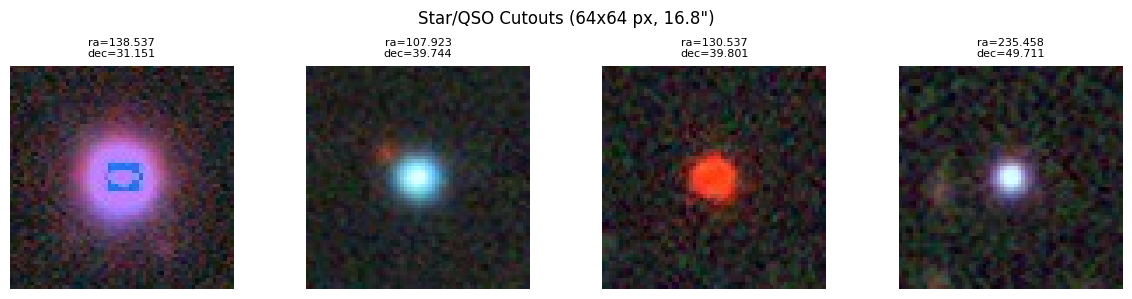

成功下载 4/16 张图像


In [29]:
# 测试恒星/QSO cutout
nongal_data = Table.read('./NonGal/LSDR10_star_qso_DESI_SDSS_merged.fits')
print(f"恒星/QSO 数据量: {len(nongal_data)} 条")

test_download_and_visualize(nongal_data, n_samples=16, size=64, title="Star/QSO Cutouts")

星系数据量: 3000000 条


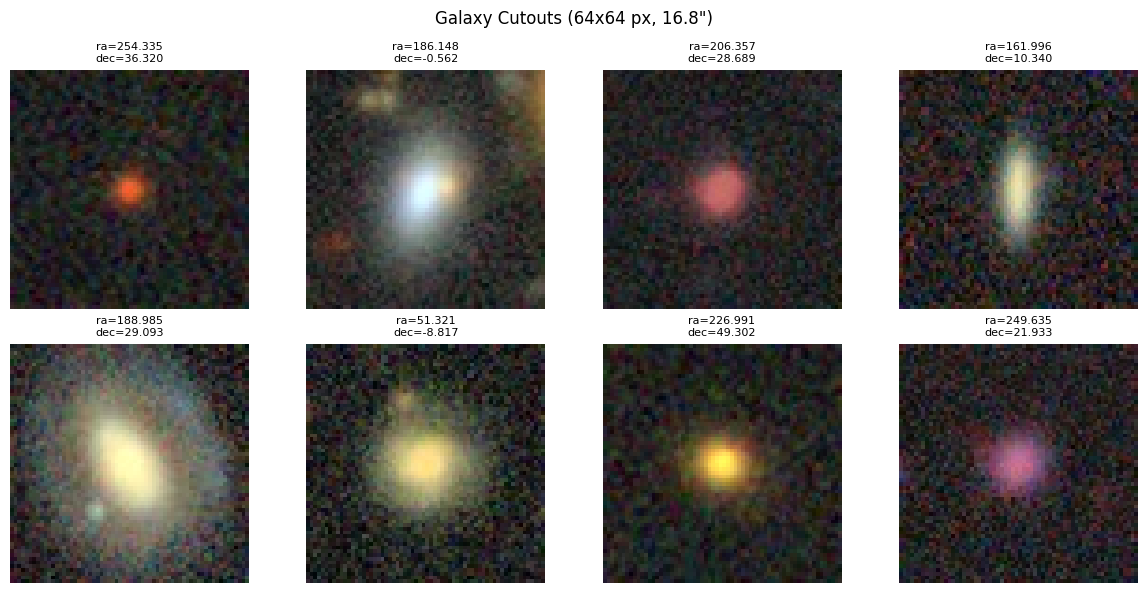

成功下载 8/16 张图像


In [31]:
# 测试星系 cutout
galaxy_data = Table.read('./NonGal/LSDR10_galaxy_DESI_SDSS_3M.fits')
print(f"星系数据量: {len(galaxy_data)} 条")

test_download_and_visualize(galaxy_data, n_samples=16, size=64, title="Galaxy Cutouts")

=== 64x64 像素 (16.8") ===


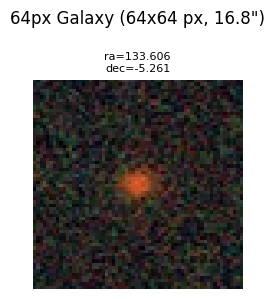

成功下载 1/4 张图像

=== 128x128 像素 (33.5") ===


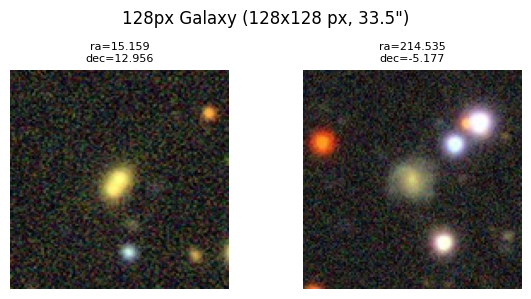

成功下载 2/4 张图像


In [32]:
# 对比不同图像尺寸
print("=== 64x64 像素 (16.8\") ===")
test_download_and_visualize(galaxy_data, n_samples=4, size=64, title="64px Galaxy")

print("\n=== 128x128 像素 (33.5\") ===")
test_download_and_visualize(galaxy_data, n_samples=4, size=128, title="128px Galaxy")

### 批量下载说明

测试确认cutout服务正常后，使用命令行脚本进行批量下载：

```bash
# 下载星系图像 (约300万张)
python download_cutout.py --type galaxy

# 下载恒星/QSO图像 (约300万张)  
python download_cutout.py --type nongal

# 测试模式 (只下载前1000张)
python download_cutout.py --type galaxy --limit 1000

# 自定义参数
python download_cutout.py --type galaxy --size 128 --workers 16 --batch-size 5000
```

特性：
- 支持断点续传（按batch保存checkpoint）
- 多线程并行下载
- 自动重试失败的请求
- 保存为HDF5格式，包含图像和坐标信息

In [ ]:
# 查看已下载的HDF5文件（如果存在）
import h5py
import os

h5_files = [
    './NonGal/cutouts_galaxy_64.h5',
    './NonGal/cutouts_nongal_64.h5',
]

for h5_path in h5_files:
    if os.path.exists(h5_path):
        print(f"\n=== {h5_path} ===")
        with h5py.File(h5_path, 'r') as f:
            for key in f.keys():
                dset = f[key]
                print(f"  {key}: shape={dset.shape}, dtype={dset.dtype}")
    else:
        print(f"\n{h5_path} 不存在（尚未下载）")

In [ ]:
# 可视化已下载的HDF5图像（如果存在）
h5_path = './NonGal/cutouts_galaxy_64.h5'
dataset_name = 'galaxy'

if os.path.exists(h5_path):
    with h5py.File(h5_path, 'r') as f:
        if dataset_name in f:
            n_images = min(16, f[dataset_name].shape[0])
            images = f[dataset_name][:n_images]
            ras = f[f'{dataset_name}_ra'][:n_images]
            decs = f[f'{dataset_name}_dec'][:n_images]
            
            ncols = 4
            nrows = (n_images + ncols - 1) // ncols
            fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3*nrows))
            axes = axes.flatten()
            
            for i in range(n_images):
                axes[i].imshow(images[i])
                axes[i].set_title(f"ra={ras[i]:.3f}\ndec={decs[i]:.3f}", fontsize=8)
                axes[i].axis('off')
            
            for j in range(n_images, len(axes)):
                axes[j].axis('off')
            
            plt.suptitle(f"Downloaded Galaxy Cutouts from HDF5", fontsize=12)
            plt.tight_layout()
            plt.show()
else:
    print(f"{h5_path} 不存在，请先运行 download_cutout.py --type galaxy")